# Análisis de precios de viviendas en California

**Objetivo:** identificar qué características están más relacionadas con el precio de las viviendas en California mediante un análisis exploratorio de datos.

El notebook sigue el orden solicitado en el desafío:

**exploración → limpieza/preprocesamiento → análisis simple → análisis multivariado**

La intención es mantener el análisis claro y justificable, sin agregar modelos predictivos ni complejidad innecesaria.


## 1. Carga y exploración inicial

Antes de modificar los datos revisamos su tamaño, columnas, tipos de datos, valores faltantes y primeras filas.




In [1]:
# Importamos las librerías necesarias para manipulación, cálculo y visualización de datos.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Establece un estilo visual uniforme para todos los gráficos.
sns.set_theme(style="whitegrid")

# Ruta del CSV y carga del archivo en un DataFrame.
ruta_archivo = os.getenv("RUTA_ARCHIVO")
df_california = pd.read_csv(ruta_archivo)

# shape muestra filas y columnas del dataset.
print("Dimensiones:", df_california.shape)

# isnull().sum() cuenta los valores faltantes por columna.
print("\nValores faltantes:")
print(df_california.isnull().sum())

# duplicated().sum() cuenta filas completamente repetidas.
print("\nFilas duplicadas completas:", df_california.duplicated().sum())

# head(3) permite verificar rápidamente que los datos fueron cargados correctamente.
df_california.head(3)


Dimensiones: (20640, 10)

Valores faltantes:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Filas duplicadas completas: 0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


In [2]:
# info() resume nombres de columnas, tipos de datos y cantidad de valores no nulos.
df_california.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [3]:
# describe() genera estadísticas básicas de las variables numéricas:
# cantidad, media, desviación, mínimo, cuartiles y máximo.
df_california.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Qué observamos inicialmente

El dataset contiene **20.640 registros y 10 columnas**.  
La variable `total_bedrooms` contiene **207 valores faltantes** y `ocean_proximity` es la principal variable categórica.

Las variables más importantes para la pregunta del desafío son:

- `median_house_value`: precio mediano de la vivienda.
- `median_income`: ingreso mediano de la zona.
- `housing_median_age`: edad mediana de las viviendas.
- `ocean_proximity`: cercanía al océano.
- `longitude` y `latitude`: ubicación geográfica.

**Para la defensa:** `median_house_value` es nuestra variable principal porque queremos descubrir qué características se relacionan con el precio.


## 2. Limpieza y preprocesamiento

Solo existe un problema evidente de valores faltantes en `total_bedrooms`.

Usamos la **mediana** para imputarlos porque es menos sensible que la media a valores extremos.

También creamos una copia con **One-Hot Encoding** para poder incluir `ocean_proximity` en cálculos numéricos como la correlación. Conservamos el DataFrame original con la categoría legible para los gráficos.


In [4]:
# Calculamos la mediana de total_bedrooms.
# La mediana es menos sensible a valores extremos que la media.
mediana_habitaciones = df_california['total_bedrooms'].median()

# fillna() reemplaza únicamente los valores faltantes por la mediana calculada.
df_california['total_bedrooms'] = df_california['total_bedrooms'].fillna(mediana_habitaciones)

# One-Hot Encoding:
# get_dummies() convierte ocean_proximity en columnas binarias de 0 y 1.
# Conservamos df_california sin modificar para seguir usando la categoría original en los gráficos.
df_encoded = pd.get_dummies(
    df_california,
    columns=['ocean_proximity'],
    dtype=int
)

# Verificamos que no queden valores faltantes después de la imputación.
print("Valores faltantes después de la limpieza:")
print(df_california.isnull().sum().sum())


Valores faltantes después de la limpieza:
0


## 3. Distribución individual del precio

Primero analizamos `median_house_value` de manera aislada.

El histograma permite observar dónde se concentran los precios, la forma de la distribución y posibles valores extremos.


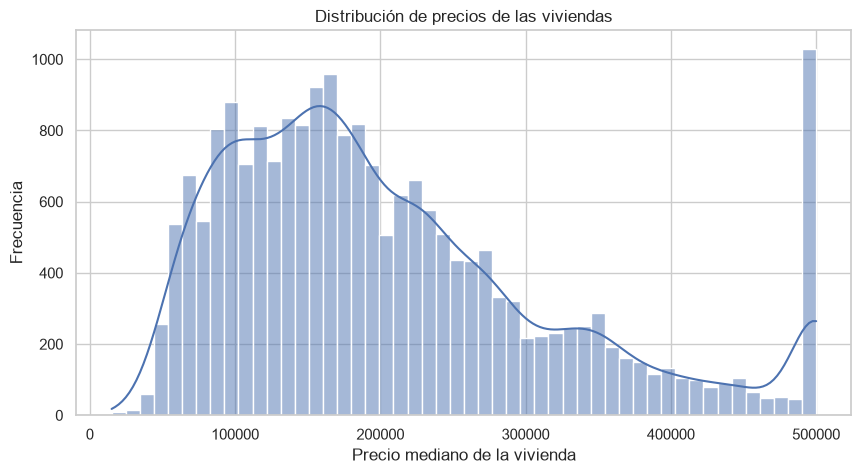

Precio máximo registrado: 500001.0
Cantidad de registros exactamente en el máximo: 965


In [5]:
# Histograma del precio:
# bins=50 divide el rango de precios en 50 intervalos.
# kde=True añade una curva suavizada para observar mejor la forma general de la distribución.
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_california,
    x='median_house_value',
    bins=50,
    kde=True
)

plt.title('Distribución de precios de las viviendas')
plt.xlabel('Precio mediano de la vivienda')
plt.ylabel('Frecuencia')
plt.show()

# max() obtiene el mayor precio registrado.
precio_max = df_california['median_house_value'].max()

# Contamos cuántos registros están exactamente en ese máximo para detectar una posible acumulación.
print("Precio máximo registrado:", precio_max)
print(
    "Cantidad de registros exactamente en el máximo:",
    (df_california['median_house_value'] == precio_max).sum()
)


El histograma responde a “¿cómo se distribuye una variable?”. No explica por sí solo por qué una vivienda es cara.


## 4. Distribuciones segmentadas

Ahora comparamos el precio utilizando distintas características.

### 4.1 Precio según antigüedad

Dividimos las zonas en dos grupos simples:

- viviendas con edad mediana menor a 20 años;
- viviendas con edad mediana de 20 años o más.

El objetivo no es afirmar que 20 años sea una frontera universal, sino crear una segmentación sencilla para comparar las distribuciones.


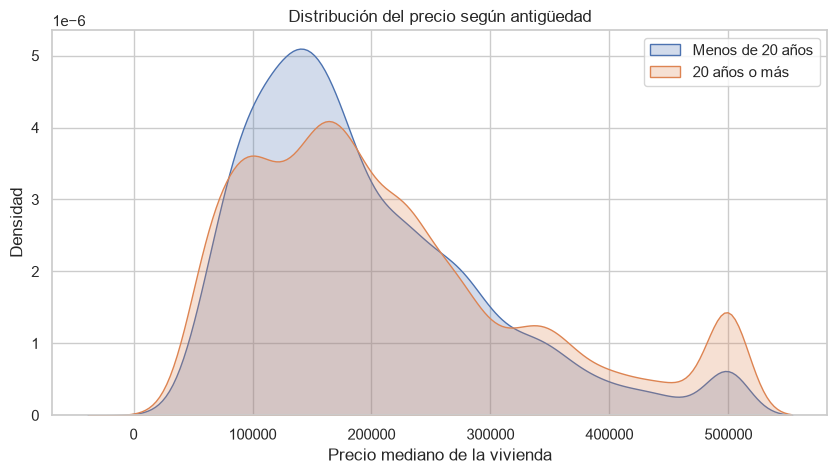

In [6]:
# Filtramos el dataset en dos grupos según housing_median_age.
# El valor 20 se usa como una división simple para comparar distribuciones.
casas_nuevas = df_california[df_california['housing_median_age'] < 20]
casas_antiguas = df_california[df_california['housing_median_age'] >= 20]

plt.figure(figsize=(10, 5))

# kdeplot muestra una estimación suavizada de la distribución de precios.
# fill=True rellena el área bajo cada curva para facilitar la comparación visual.
sns.kdeplot(
    casas_nuevas['median_house_value'],
    label='Menos de 20 años',
    fill=True
)

sns.kdeplot(
    casas_antiguas['median_house_value'],
    label='20 años o más',
    fill=True
)

plt.title('Distribución del precio según antigüedad')
plt.xlabel('Precio mediano de la vivienda')
plt.ylabel('Densidad')
plt.legend()
plt.show()


### Conclusiones del gráfico - Distribución del precio

- La distribución de `median_house_value` no es completamente simétrica.
- La mayor parte de los registros se concentra en rangos intermedios.
- Se observa una acumulación de valores en el extremo superior.

**Hallazgo:** La concentración de registros exactamente en el valor máximo sugiere que `median_house_value` puede tener un límite superior de registro.




### 4.2 Precio según cercanía al océano

Aquí usamos una segmentación directamente relacionada con la pregunta del desafío: comprobar si la ubicación respecto al océano está asociada con diferencias de precio.


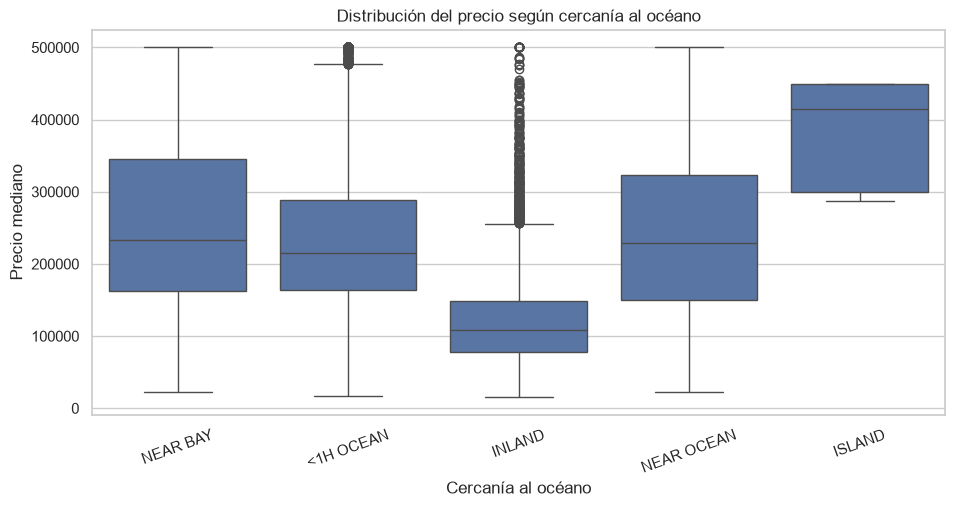

In [7]:
# El boxplot compara la distribución del precio entre categorías de cercanía al océano.
# x define los grupos y y la variable numérica que queremos comparar.
plt.figure(figsize=(11, 5))

sns.boxplot(
    data=df_california,
    x='ocean_proximity',
    y='median_house_value'
)

plt.title('Distribución del precio según cercanía al océano')
plt.xlabel('Cercanía al océano')
plt.ylabel('Precio mediano')
plt.xticks(rotation=20)
plt.show()


### Conclusiones del gráfico - Distribución del precio según antigüedad

- Las curvas permiten comparar la distribución de precios entre viviendas de menos de 20 años y viviendas de 20 años o más.
- Existe superposición entre ambos grupos, por lo que la antigüedad no separa completamente los precios.
- La edad de la vivienda por sí sola no parece explicar el valor de manera contundente.

**Hallazgo:** La antigüedad modifica la distribución del precio, pero no aparece como una variable suficiente para explicar por sí sola las diferencias del mercado.


El boxplot permite comparar mediana, dispersión y valores extremos entre categorías. Es más informativo que comparar únicamente un promedio.


## 5. Análisis simple: precio mediano por cercanía al océano

Agrupamos por `ocean_proximity` y calculamos la mediana del precio.

La pregunta ahora es concreta:

**¿Qué categorías de cercanía al océano presentan precios típicos más altos?**


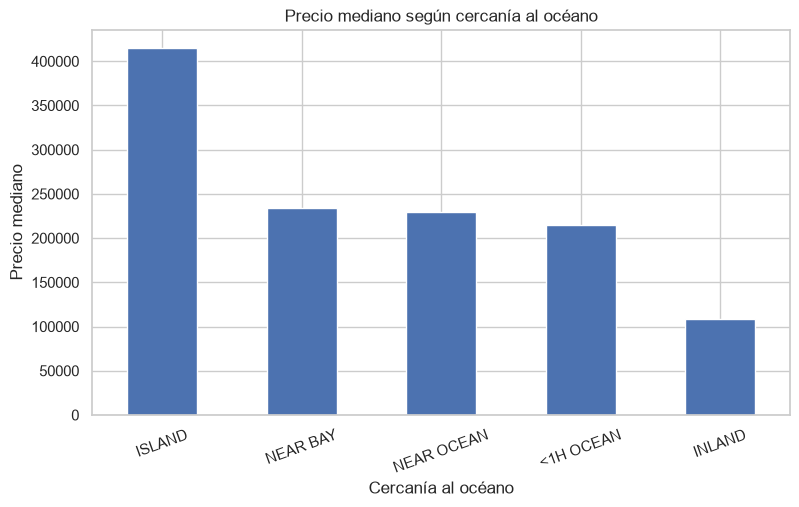

ocean_proximity
ISLAND        414700.0
NEAR BAY      233800.0
NEAR OCEAN    229450.0
<1H OCEAN     214850.0
INLAND        108500.0
Name: median_house_value, dtype: float64


In [8]:
# groupby() agrupa las viviendas según ocean_proximity.
# median() calcula el precio típico de cada grupo reduciendo el efecto de valores extremos.
# sort_values() ordena las categorías de mayor a menor precio.
precio_por_oceano = (
    df_california
    .groupby('ocean_proximity')['median_house_value']
    .median()
    .sort_values(ascending=False)
)

# El gráfico de barras permite comparar fácilmente el precio mediano entre categorías.
plt.figure(figsize=(9, 5))
precio_por_oceano.plot(kind='bar')

plt.title('Precio mediano según cercanía al océano')
plt.xlabel('Cercanía al océano')
plt.ylabel('Precio mediano')
plt.xticks(rotation=20)
plt.show()

print(precio_por_oceano)


### Conclusiones del gráfico - Boxplot por cercanía al océano

- La línea central de cada caja representa la mediana.
- La caja contiene aproximadamente el 50 % central de los datos.
- Los bigotes muestran el rango habitual y los puntos alejados pueden representar valores atípicos.
- `INLAND` presenta una mediana claramente menor que las zonas cercanas al océano.

**Hallazgo:** La ubicación respecto al océano está asociada con diferencias importantes en el precio de las viviendas.

**Importante:** Un valor atípico no debe considerarse automáticamente un error.




Este gráfico permite evaluar de forma directa si las zonas costeras tienden a presentar precios diferentes de las zonas `INLAND`.


## 6. Correlación entre variables

La correlación mide la intensidad de una **relación lineal** entre variables.

Su valor se encuentra entre -1 y 1:

- cercano a 1: relación positiva fuerte;
- cercano a -1: relación negativa fuerte;
- cercano a 0: poca relación lineal.

**Importante:** correlación no implica causalidad.


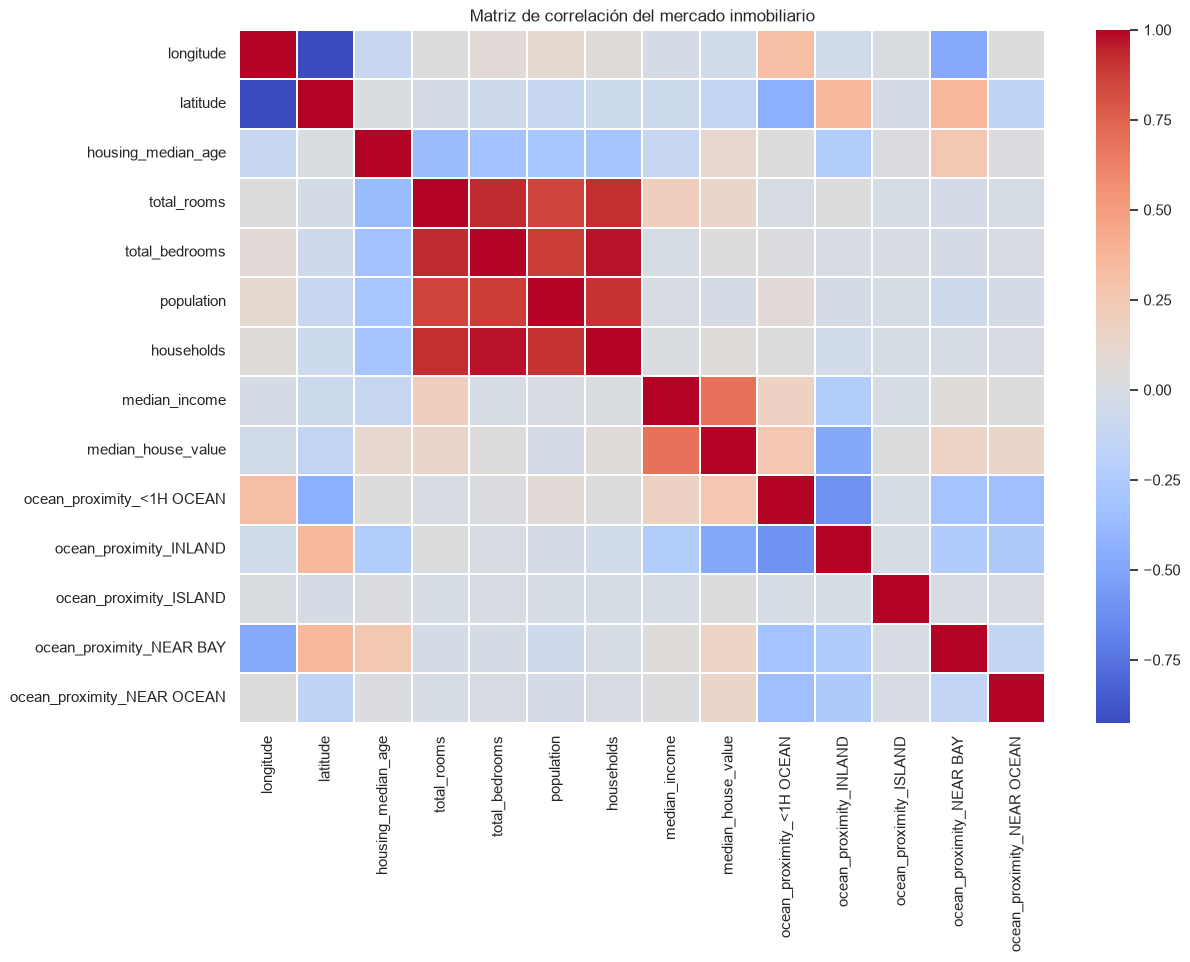

Variables con mayor correlación con el precio:
median_income                 0.688075
ocean_proximity_<1H OCEAN     0.256617
ocean_proximity_NEAR BAY      0.160284
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
Name: median_house_value, dtype: float64


In [9]:
# corr() calcula la correlación lineal entre todas las variables numéricas.
# numeric_only=True evita incluir columnas que no puedan tratarse como números.
matriz_correlacion = df_encoded.corr(numeric_only=True)

plt.figure(figsize=(13, 9))

# El heatmap convierte la matriz de correlación en un mapa visual.
# cmap='coolwarm' diferencia relaciones negativas y positivas.
# annot=False evita saturar el gráfico con demasiados valores escritos.
sns.heatmap(
    matriz_correlacion,
    annot=False,
    cmap='coolwarm',
    linewidths=0.3
)

plt.title('Matriz de correlación del mercado inmobiliario')
plt.show()

# Seleccionamos las 5 variables con mayor correlación positiva respecto al precio.
print("Variables con mayor correlación con el precio:")
print(
    matriz_correlacion['median_house_value']
    .drop('median_house_value')
    .sort_values(ascending=False)
    .head(5)
)


### Conclusiones del gráfico - Precio mediano según cercanía al océano

- `ISLAND` presenta el precio mediano más alto.
- `NEAR BAY` y `NEAR OCEAN` muestran precios medianos superiores a `INLAND`.
- `INLAND` presenta claramente el precio mediano más bajo.
- `<1H OCEAN` se encuentra en una posición intermedia.

**Hallazgo:** Las zonas alejadas del océano tienden a mostrar precios considerablemente menores que las zonas costeras.

**Importante:** La categoría `ISLAND` debe interpretarse con cautela porque puede contener muchas menos observaciones que las demás.


En la ejecución original del notebook, `median_income` presentó una correlación aproximada de **0,69** con `median_house_value`, siendo la relación lineal positiva más destacada entre las variables analizadas.




## 7. Pairplot de variables clave

El pairplot permite observar simultáneamente las distribuciones individuales y las relaciones entre varias variables.

Como el dataset tiene más de 20.000 registros, usamos una muestra de 1.000 únicamente para visualizar con mayor claridad y rapidez.


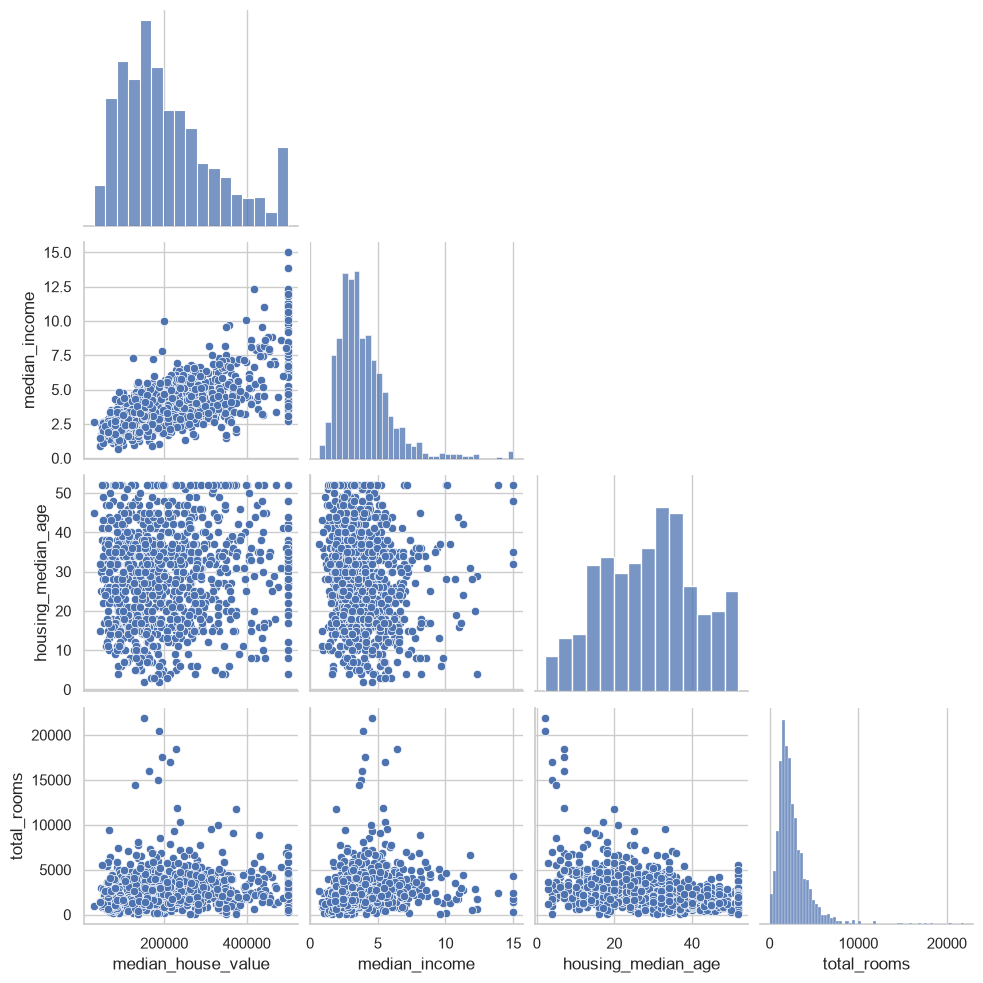

In [10]:
# Elegimos un conjunto pequeño de variables relevantes para evitar un pairplot demasiado cargado.
columnas_clave = [
    'median_house_value',
    'median_income',
    'housing_median_age',
    'total_rooms'
]

# dropna() elimina filas incompletas solo para esta visualización.
# sample(1000) reduce el costo gráfico y random_state=42 hace reproducible la muestra.
muestra_pairplot = (
    df_california[columnas_clave]
    .dropna()
    .sample(1000, random_state=42)
)

# pairplot muestra distribuciones individuales y relaciones entre pares de variables.
# corner=True evita repetir los mismos gráficos de forma simétrica.
sns.pairplot(
    muestra_pairplot,
    corner=True
)

plt.show()


### Conclusiones del gráfico - Matriz de correlación

- Los valores cercanos a 1 indican una relación lineal positiva fuerte.
- Los valores cercanos a -1 indican una relación negativa.
- Los valores cercanos a 0 indican poca relación lineal.
- `median_income` presenta la relación positiva más fuerte con `median_house_value`, con una correlación aproximada de 0,69.
- `ocean_proximity_INLAND` muestra una asociación negativa con el precio.

**Hallazgo:** El ingreso mediano destaca como la variable numérica más relacionada con el precio, mientras que la ubicación `INLAND` se asocia con precios menores.

**Importante:** Correlación no implica causalidad.


## 8. Análisis multivariado: ingreso, precio y cercanía al océano

Terminamos combinando tres elementos:

- `median_income`;
- `median_house_value`;
- `ocean_proximity`.

Esto permite responder una pregunta más compleja:

**¿La relación entre ingreso y precio se comporta igual en todas las zonas o también interviene la ubicación respecto al océano?**


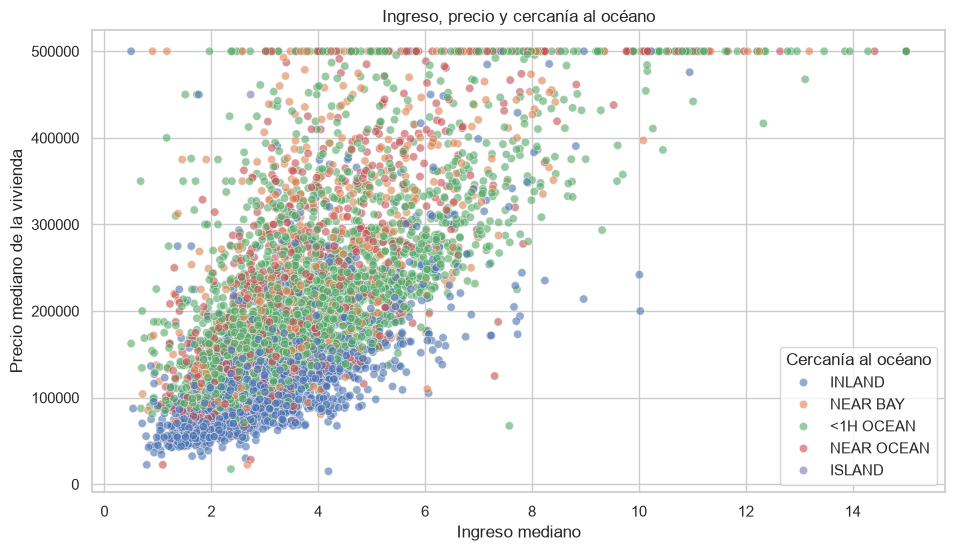

In [11]:
# Tomamos una muestra de 5000 registros para mantener el scatterplot legible.
# random_state=42 permite reproducir exactamente la misma selección.
muestra_compleja = df_california.sample(5000, random_state=42)

plt.figure(figsize=(11, 6))

# scatterplot compara ingreso y precio.
# hue='ocean_proximity' añade una tercera variable mediante categorías de color.
# alpha=0.6 agrega transparencia para distinguir mejor zonas con muchos puntos superpuestos.
sns.scatterplot(
    data=muestra_compleja,
    x='median_income',
    y='median_house_value',
    hue='ocean_proximity',
    alpha=0.6
)

plt.title('Ingreso, precio y cercanía al océano')
plt.xlabel('Ingreso mediano')
plt.ylabel('Precio mediano de la vivienda')
plt.legend(title='Cercanía al océano')
plt.show()


### Conclusiones del gráfico - Pairplot

- Se observa una tendencia ascendente clara entre `median_income` y `median_house_value`.
- `housing_median_age` presenta una relación mucho más dispersa con el precio.
- `total_rooms` tampoco muestra una relación lineal fuerte con `median_house_value`.
- Se aprecia una concentración de valores alrededor del máximo de precio registrado.

**Hallazgo:** El pairplot confirma visualmente que el ingreso mediano tiene una relación más clara con el precio que la edad o el número total de habitaciones.

La muestra de 1.000 registros se utiliza únicamente para visualización y no modifica el dataset original.


### Interpretación

Este gráfico permite comprobar simultáneamente que:

1. el ingreso mediano está relacionado con el precio;
2. viviendas con ingresos similares pueden presentar precios diferentes;
3. la ubicación respecto al océano aporta información adicional para explicar esas diferencias.

Por eso no conviene buscar una única variable que “cause” el precio. El mercado inmobiliario es multivariable.


## 9. Conclusiones

El análisis exploratorio permite responder la pregunta principal sin utilizar modelos predictivos.

Los puntos principales para la defensa son:

- `median_income` presenta una de las relaciones lineales más fuertes con el precio.
- `ocean_proximity` permite observar diferencias claras entre segmentos del mercado.
- La edad de la vivienda puede modificar la distribución de precios, pero no explica el precio por sí sola.
- El precio depende de varias características simultáneamente; por eso el análisis multivariado es más útil que observar una sola columna.
- Los gráficos muestran asociaciones y patrones, pero no prueban causalidad.

### Idea central de la defensa

La historia del notebook avanza desde una pregunta simple —**cómo se distribuyen los precios**— hasta una pregunta multivariada —**cómo se relacionan ingreso, precio y ubicación**—. Cada gráfico fue elegido para responder una pregunta específica y no solamente para cumplir un requisito.
